# MLP Classification




## Learning goals

- Understand the matrix operations inside an MLP.
- Train and evaluate a reproducible classifier.
- Save preprocessing and the model together in a pipeline.
- Inspect weights, biases, scaling parameters, and predictions.
- Connect the Python implementation to an Excel or mathematical implementation.
- Evaluate a model using evidence rather than only a single accuracy number.

## Part 1: Load and understand the data

The Palmer Penguins dataset contains measurements of three penguin species. Before modeling, inspect the variables, missing values, class balance, and units.

### Observación de la siguiente celda

`penguins.head()` sirve para hacer una **inspección rápida**, no para obtener conclusiones estadísticas. Verifica que aparezcan columnas como `species`, `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` y `sex`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Class counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


KeyboardInterrupt: 

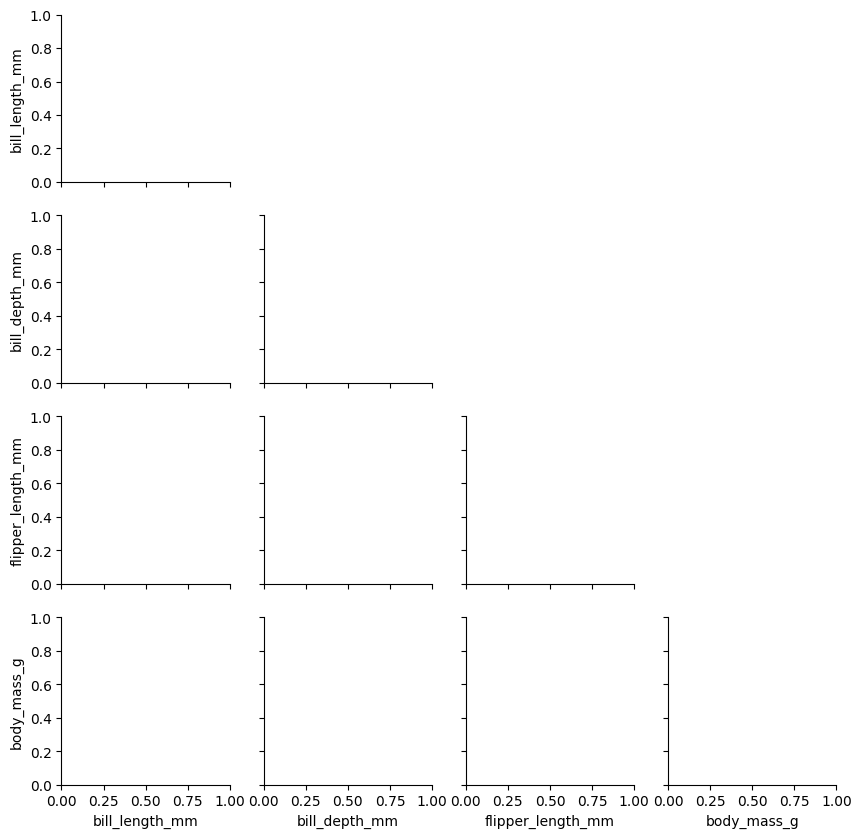

In [4]:
print(penguins.info())
print("\nMissing values:")
print(penguins.isna().sum())
print("\nClass counts:")
print(penguins["species"].value_counts())

sns.pairplot(penguins, hue="species", corner=True)
plt.show()

---
## Antes de la Part 2 — Preparación de datos

### Qué hacer
1. Eliminar filas incompletas con `dropna()`.
2. Separar las variables predictoras (`X`) de la variable objetivo (`y`).
3. Convertir variables categóricas a números.

### Fin de este paso
El MLP realiza operaciones matemáticas con matrices, por lo que necesita entradas numéricas y completas.

### Idea clave
\[
X=\text{variables de entrada}, \qquad y=\text{clase que queremos predecir}
\]

### Atención
Codificar `Biscoe=0`, `Dream=1`, `Torgersen=2` es sencillo, pero puede introducir una noción artificial de orden. Esta es una **limitación que puedes mencionar en la discusión**.


## Part 2: Prepare features without losing reproducibility

We remove incomplete rows and encode the two categorical variables. The pipeline will standardize numeric columns during training. Keeping preprocessing inside the pipeline prevents applying a different transformation during prediction.

### Qué debes comprobar

Después de esta celda, `X` debe contener solo números. Revisa `X.head()` y confirma que no queden textos en `sex` ni `island`.

**Pregunta para ti:** ¿los números asignados a las islas significan que una isla es matemáticamente mayor que otra? No. Solo son códigos.


In [ ]:
penguins = penguins.dropna().copy()

X = penguins.drop(columns=["species"])
y = penguins["species"]

X["sex"] = X["sex"].map({"Male": 0, "Female": 1})
X["island"] = X["island"].map({"Biscoe": 0, "Dream": 1, "Torgersen": 2})

print(X.dtypes)
X.head()

---
## Antes de la Part 3 — Entrenamiento del modelo base

Esta parte crea el **baseline model**, es decir, el modelo de referencia contra el cual compararás después el modelo optimizado.

### Arquitectura base

`hidden_layer_sizes=(20, 10)` significa:

\[
6\;\text{inputs}\rightarrow20\;\text{neurons}\rightarrow10\;\text{neurons}\rightarrow3\;\text{classes}
\]

### Muy importante para tu investigación
El notebook original usa una división concreta de entrenamiento/prueba. La investigación pide utilizar **otra división**. En la sección de trabajo individual de esta versión usaremos otro `random_state` y volveremos a entrenar ambos modelos con exactamente esa misma nueva división.


## Part 3: Train and evaluate an MLP pipeline

An MLP applies affine transformations and nonlinear activation functions. Here, `StandardScaler` and `MLPClassifier` are stored as one object.

### Qué hace cada elemento importante

- `test_size=0.2`: reserva aproximadamente 20 % para evaluación final.
- `random_state`: hace reproducible la división.
- `stratify=y`: conserva aproximadamente la proporción de especies en train y test.
- `StandardScaler()`: transforma cada variable aproximadamente como

\[
z=\frac{x-\mu}{\sigma}
\]

- `Pipeline`: mantiene el escalado y el modelo unidos para evitar aplicar transformaciones inconsistentes.
- `MLPClassifier`: entrena la red neuronal.

### Qué debes observar después
Compara `accuracy`, `precision`, `recall`, `F1-score` y la matriz de confusión. **No concluyas solo con accuracy.**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf = confusion_matrix(y_test, y_pred)
sns.heatmap(
    conf, annot=True, cmap="Blues",
    xticklabels=model_pipeline.classes_,
    yticklabels=model_pipeline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## Antes de la Part 4 — ¿Cómo aprende la red?

El entrenamiento repite esencialmente:

1. **Forward pass:** calcula una predicción.
2. **Loss:** mide el error.
3. **Backpropagation:** calcula cómo contribuyó cada parámetro al error.
4. **Gradient descent / optimizer:** ajusta pesos y sesgos para reducir la pérdida.

El gráfico `loss_curve_` te permite comprobar si el error disminuye durante el entrenamiento.


## Part 4: Backpropagation and gradient descent

Training the MLP has four main steps:

1. **Forward pass:** compute the prediction from the input.
2. **Loss:** measure the difference between the prediction and the target.
3. **Backpropagation:** use the chain rule to calculate the gradient of the loss with respect to each weight.
4. **Gradient descent:** update the weights using the learning rate:

$$
W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial L}{\partial W^{(l)}}
$$

Here, $\eta$ is the learning rate. `MLPClassifier` performs these calculations internally.

### Qué debes observar en la curva de pérdida

La tendencia general debería disminuir y luego estabilizarse. Si la pérdida no disminuye, oscila demasiado o el algoritmo llega a `max_iter` sin converger, eso puede indicar que debes ajustar hiperparámetros, escalado o número de iteraciones.

Anota también `classifier.n_iter_`: lo necesitarás más adelante para comparar el modelo base y el optimizado.


In [ ]:
classifier = model_pipeline.named_steps["classifier"]

plt.plot(classifier.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss during backpropagation")
plt.show()

print("Training iterations:", classifier.n_iter_)
print("Final loss:", classifier.loss_)

---
## Antes de la Part 5 — Forward pass matemático

Esta parte es esencial para la entrega porque luego tendrás que reproducir **al menos una predicción fuera de Python**, preferiblemente en Excel o Google Sheets.

Para una observación escalada `x`:

\[
z^{(1)}=xW_1+b_1, \qquad a^{(1)}=\operatorname{ReLU}(z^{(1)})
\]

\[
z^{(2)}=a^{(1)}W_2+b_2, \qquad a^{(2)}=\operatorname{ReLU}(z^{(2)})
\]

\[
z^{(3)}=a^{(2)}W_3+b_3
\]

Finalmente Softmax transforma los scores en probabilidades.

**Objetivo:** entender que `predict_proba()` es el resultado final de estas operaciones, no magia.


## Part 5: The mathematical forward pass

For one standardized input vector $x$, each hidden layer computes

$$z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = \operatorname{ReLU}(z^{(l)})$$

The output layer produces class scores and probabilities. In a multiclass classifier, the probabilities are obtained with softmax:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

The following code exposes the learned parameters.

### Qué debes identificar en la salida

- `classes_` → orden de las clases de salida.
- `coefs_` → matrices de pesos.
- `intercepts_` → vectores de sesgos.
- `scaler.mean_` y `scaler.scale_` → parámetros necesarios para estandarizar exactamente igual en Excel.

El orden importa muchísimo: si cambias el orden de las características o de las clases, la reproducción manual será incorrecta.


In [ ]:
classifier = model_pipeline.named_steps["classifier"]
scaler = model_pipeline.named_steps["scaler"]

print("Classes:", classifier.classes_)
print("Weight matrix shapes:", [w.shape for w in classifier.coefs_])
print("Bias vector shapes:", [b.shape for b in classifier.intercepts_])
print("Scaler means:", scaler.mean_)
print("Scaler scales:", scaler.scale_)

---
## Antes de la Part 6 — Guardar y reutilizar el modelo

Guardar el **pipeline completo** es mejor que guardar solamente el MLP, porque el pipeline contiene también el `StandardScaler`.

### Fin de este paso
Poder cargar el modelo posteriormente y predecir nuevos datos usando exactamente el mismo preprocesamiento que durante el entrenamiento.


## Part 6: Save, reload, and predict

The complete pipeline includes preprocessing and the classifier. New observations must use the original feature scale.

### Qué comprobar

Después de guardar y volver a cargar el pipeline, una predicción debería ser consistente con la realizada antes de guardar. Esto demuestra reproducibilidad del modelo.


In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(model_pipeline, "models/trained_mlp_penguins.joblib")

loaded_pipeline = joblib.load("models/trained_mlp_penguins.joblib")
print(loaded_pipeline)

### Observación

Esta celda representa **inferencia**: usar un modelo ya entrenado con una observación nueva. El nuevo registro debe tener las mismas columnas, en el mismo significado, que los datos usados para entrenar.


In [ ]:
new_penguin = pd.DataFrame({
    "island": [0],
    "bill_length_mm": [50.0],
    "bill_depth_mm": [15.0],
    "flipper_length_mm": [200.0],
    "body_mass_g": [4000.0],
    "sex": [0]
})

prediction = loaded_pipeline.predict(new_penguin)
probabilities = loaded_pipeline.predict_proba(new_penguin)[0]

print("Predicted species:", prediction[0])
print(dict(zip(loaded_pipeline.classes_, probabilities)))

---
## Antes de la Part 7 — Exportar parámetros

Esta parte prepara los elementos que necesitarás para Excel/Google Sheets.

### Debes exportar
- medias del scaler;
- escalas del scaler;
- matrices de pesos;
- vectores de bias;
- orden de las clases.

### Fin de este paso
Poder reconstruir la predicción **sin llamar a `MLPClassifier.predict_proba()`**.


## Part 7: Export parameters for Excel

Exporting parameters is useful for learning and auditing. It is not the same as exporting a production-ready model: Excel must still reproduce scaling, matrix multiplication, ReLU, and softmax correctly.

### Qué debes revisar en la carpeta exportada

Confirma que se creen archivos para `scaler`, cada matriz `W`, cada vector `b` y, para tu entrega final, también un archivo con las clases. Más abajo agregaremos una exportación completa para el **mejor modelo optimizado**.


In [ ]:
os.makedirs("weights_and_biases", exist_ok=True)

pd.DataFrame({"feature": X.columns, "mean": scaler.mean_, "scale": scaler.scale_}).to_excel(
    "weights_and_biases/scaler_parameters.xlsx", index=False
)

for layer_index, weights in enumerate(classifier.coefs_, start=1):
    pd.DataFrame(weights).to_excel(
        f"weights_and_biases/layer_{layer_index}_weights.xlsx",
        index=False
    )

for layer_index, biases in enumerate(classifier.intercepts_, start=1):
    pd.DataFrame(biases, columns=["bias"]).to_excel(
        f"weights_and_biases/layer_{layer_index}_biases.xlsx",
        index=False
    )

print("Export completed.")

### Traducción práctica de la guía de Excel

Para una sola observación deberás mostrar las fórmulas, no solo el resultado:

1. **Standardization:** `(value - mean) / scale`.
2. **Layer 1:** `standardized_input × W1 + b1`.
3. **ReLU:** `MAX(0, z)` para cada neurona oculta.
4. Repetir para las demás capas ocultas.
5. **Output scores:** última multiplicación + bias.
6. **Softmax:** convertir scores a probabilidades.
7. Elegir la clase de mayor probabilidad.
8. Comparar contra `predict_proba()` de Python.

Una diferencia pequeñísima por redondeo es normal; una diferencia grande indica que algo está mal en el orden, escalado o fórmulas.


### Excel implementation guide

1. Standardize each input feature with `(value - mean) / scale`.
2. Compute each neuron as a weighted sum plus its bias.
3. Apply ReLU to hidden-layer values: `MAX(0, value)`.
4. Apply softmax to the final class scores.
5. Compare the Excel probabilities with `predict_proba`.

For an MLP with several hidden layers, repeat steps 2 and 3 for each hidden layer.

---
# Part 8 — Tu investigación individual: versión guiada

A partir de aquí comienza la parte que debes **adaptar, ejecutar, analizar y presentar**.

## Entregables que debes obtener

- una nueva división train/test diferente de la usada en el ejemplo;
- modelo base con `(20, 10)`;
- búsqueda de hiperparámetros con `GridSearchCV` o `RandomizedSearchCV`;
- mejores hiperparámetros y score de validación cruzada;
- evaluación final en el test set;
- tabla baseline vs optimized;
- accuracy, macro F1, iteraciones y número de parámetros;
- al menos una gráfica o tabla creada por ti;
- exportación del mejor modelo;
- forward pass completo en Excel/Google Sheets;
- comparación de probabilidades con `predict_proba()`;
- una limitación, una mejora y una explicación sobre causalidad.


## 8.1 Crear una nueva división Train/Test

### Qué tienes que hacer
Usar **la misma `X` e `y` ya preparadas**, pero una división distinta de la del ejemplo.

Aquí usamos `random_state=17` para generar una partición reproducible diferente.

### Por qué
Para que tu investigación no repita exactamente los resultados del notebook demostrativo.

### Regla importante
Esta nueva división debe usarse tanto para el baseline como para el modelo optimizado. De esta forma la comparación es justa.


In [ ]:
from sklearn.model_selection import train_test_split

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=17,   # diferente al ejemplo original
    stratify=y
)

print("Training samples:", len(X_train_ind))
print("Test samples:", len(X_test_ind))
print("\nTraining class proportions:")
print(y_train_ind.value_counts(normalize=True))
print("\nTest class proportions:")
print(y_test_ind.value_counts(normalize=True))


### Qué debes observar
Las proporciones de las clases en `train` y `test` deberían ser parecidas gracias a `stratify=y`.

### Escribe debajo de la salida
Indica cuántos registros quedaron en entrenamiento y prueba y comenta si la distribución de especies se conserva aproximadamente.


## 8.2 Entrenar nuevamente el modelo base

### Qué tienes que hacer
Entrenar el baseline `(20,10)` **desde cero** usando la nueva división.

### Fin
Obtener una referencia válida para comparar con la optimización.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train_ind, y_train_ind)
baseline_pred = baseline_pipeline.predict(X_test_ind)

baseline_accuracy = accuracy_score(y_test_ind, baseline_pred)
baseline_macro_f1 = f1_score(y_test_ind, baseline_pred, average="macro")
baseline_clf = baseline_pipeline.named_steps["classifier"]

print("Baseline accuracy:", baseline_accuracy)
print("Baseline macro F1:", baseline_macro_f1)
print("Training iterations:", baseline_clf.n_iter_)
print("\nClassification report:\n", classification_report(y_test_ind, baseline_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_ind, baseline_pred))


### Qué debes analizar
- ¿Accuracy y Macro F1 son parecidos?
- ¿Qué especie presenta más errores?
- ¿Hay clases con peor recall o F1?
- ¿Cuántas iteraciones necesitó el modelo?

No escribas simplemente “the model is good”. Señala **qué evidencia** sustenta tu interpretación.


## 8.3 Calcular el número de parámetros

Cada conexión y cada bias es un parámetro aprendido. Una red más grande suele tener mayor capacidad, pero también mayor complejidad.

Para el baseline `(20,10)` con 6 inputs y 3 outputs:

\[
(6\times20+20)+(20\times10+10)+(10\times3+3)=383
\]

El siguiente código funciona para cualquier arquitectura entrenada.


In [ ]:
def count_mlp_parameters(classifier):
    return (
        sum(weight_matrix.size for weight_matrix in classifier.coefs_)
        + sum(bias_vector.size for bias_vector in classifier.intercepts_)
    )

baseline_parameters = count_mlp_parameters(baseline_clf)
print("Baseline parameters:", baseline_parameters)


## 8.4 Optimización con GridSearchCV

### Qué tienes que hacer
Explorar **como mínimo**:
- `hidden_layer_sizes`;
- `activation`.

Aquí añadimos también `alpha` como parámetro opcional de regularización.

### Por qué usar cross-validation
En lugar de decidir con una sola partición interna, GridSearchCV evalúa cada configuración en varios folds del conjunto de entrenamiento.

### Muy importante
El `X_test_ind` **no participa** en la búsqueda. Solo se usa después de seleccionar el mejor modelo.


In [ ]:
from sklearn.model_selection import GridSearchCV

search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        max_iter=1500,
        random_state=42
    ))
])

param_grid = {
    "classifier__hidden_layer_sizes": [
        (10,),
        (20,),
        (20, 10),
        (30, 15),
        (40, 20)
    ],
    "classifier__activation": ["relu", "tanh"],
    "classifier__alpha": [0.0001, 0.001]
}

grid_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train_ind, y_train_ind)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation macro F1:", grid_search.best_score_)


### Qué debes registrar
Copia en tu análisis:
1. los hiperparámetros encontrados;
2. el mejor `macro F1` de validación cruzada;
3. por qué elegiste `f1_macro` como métrica de búsqueda.

**No confundas:** `best_score_` es el resultado de validación cruzada sobre training, no el resultado final de test.


## 8.5 Evaluar el mejor modelo en el Test Set

Ahora sí usamos `X_test_ind`. Esta es la evaluación final sobre observaciones que no se utilizaron para seleccionar los hiperparámetros.


In [ ]:
best_pipeline = grid_search.best_estimator_
best_pred = best_pipeline.predict(X_test_ind)

optimized_accuracy = accuracy_score(y_test_ind, best_pred)
optimized_macro_f1 = f1_score(y_test_ind, best_pred, average="macro")
best_clf = best_pipeline.named_steps["classifier"]
optimized_parameters = count_mlp_parameters(best_clf)

print("Optimized accuracy:", optimized_accuracy)
print("Optimized macro F1:", optimized_macro_f1)
print("Training iterations:", best_clf.n_iter_)
print("Number of parameters:", optimized_parameters)
print("\nClassification report:\n", classification_report(y_test_ind, best_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_ind, best_pred))


## 8.6 Crear la tabla comparativa obligatoria

### Fin de esta tabla
No buscas demostrar que el modelo optimizado “siempre es mejor”. Buscas comparar **con evidencia** qué cambió en rendimiento y complejidad.


In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Hidden layers",
        "Activation",
        "Accuracy",
        "Macro F1",
        "Training iterations",
        "Number of parameters",
        "CV Macro F1"
    ],
    "Baseline": [
        str(baseline_clf.hidden_layer_sizes),
        baseline_clf.activation,
        baseline_accuracy,
        baseline_macro_f1,
        baseline_clf.n_iter_,
        baseline_parameters,
        "Not used"
    ],
    "Optimized": [
        str(best_clf.hidden_layer_sizes),
        best_clf.activation,
        optimized_accuracy,
        optimized_macro_f1,
        best_clf.n_iter_,
        optimized_parameters,
        grid_search.best_score_
    ]
})

comparison


### Qué debes escribir debajo de la tabla
Responde con números:
- ¿cambió Accuracy?
- ¿cambió Macro F1?
- ¿el modelo optimizado tiene más o menos parámetros?
- ¿necesitó más o menos iteraciones?
- ¿la mejora de rendimiento justifica el aumento de complejidad, si lo hubo?

No necesitas afirmar que uno es “mejor” en términos absolutos: describe el **trade-off observado**.


## 8.7 Crear una gráfica propia

Esta gráfica compara el Macro F1 del baseline y del modelo optimizado. Puedes conservarla como una de las evidencias requeridas.


In [ ]:
metric_plot = pd.DataFrame({
    "Model": ["Baseline", "Optimized"],
    "Macro F1": [baseline_macro_f1, optimized_macro_f1]
})

plt.figure(figsize=(6, 4))
plt.bar(metric_plot["Model"], metric_plot["Macro F1"])
plt.ylim(0, 1.05)
plt.ylabel("Macro F1")
plt.title("Baseline vs Optimized MLP")
plt.show()


## 8.8 Revisar los resultados del GridSearchCV

Esta tabla te permite ver que no solo existió una configuración. Te ayuda a justificar que la selección fue sistemática.


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_summary = cv_results[[
    "param_classifier__hidden_layer_sizes",
    "param_classifier__activation",
    "param_classifier__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

cv_summary.head(10)


## 8.9 Exportar el mejor modelo para Excel / Google Sheets

### Qué se exportará
- `scaler_parameters.csv`;
- una matriz de pesos por capa;
- un vector de bias por capa;
- `classes.csv`;
- la observación seleccionada;
- probabilidades de Python para poder compararlas con Excel.

**Usa estos archivos del modelo optimizado**, no los del baseline.


In [ ]:
import os

export_dir = "best_model_excel"
os.makedirs(export_dir, exist_ok=True)

best_scaler = best_pipeline.named_steps["scaler"]
best_classifier = best_pipeline.named_steps["classifier"]

# 1. Scaler
pd.DataFrame({
    "feature": X.columns,
    "mean": best_scaler.mean_,
    "scale": best_scaler.scale_
}).to_csv(f"{export_dir}/scaler_parameters.csv", index=False)

# 2. Weight matrices and biases
for i, W in enumerate(best_classifier.coefs_, start=1):
    pd.DataFrame(W).to_csv(f"{export_dir}/W{i}.csv", index=False)

for i, b in enumerate(best_classifier.intercepts_, start=1):
    pd.DataFrame({"bias": b}).to_csv(f"{export_dir}/b{i}.csv", index=False)

# 3. Classes
pd.DataFrame({"class": best_classifier.classes_}).to_csv(
    f"{export_dir}/classes.csv", index=False
)

print("Files exported to:", export_dir)


## 8.10 Elegir una observación y obtener la referencia de Python

Escogemos una fila del test set. **Guarda exactamente esta observación** porque será la que reconstruyas manualmente en Excel.


In [ ]:
observation = X_test_ind.iloc[[0]].copy()
true_class = y_test_ind.iloc[0]
python_prediction = best_pipeline.predict(observation)[0]
python_probabilities = best_pipeline.predict_proba(observation)[0]

print("Observation:")
display(observation)
print("True class:", true_class)
print("Python prediction:", python_prediction)
print("Python probabilities:")

probability_table = pd.DataFrame({
    "class": best_classifier.classes_,
    "python_probability": python_probabilities
})
display(probability_table)

observation.to_csv(f"{export_dir}/observation.csv", index=False)
probability_table.to_csv(f"{export_dir}/python_probabilities.csv", index=False)


# Part 9 — Forward pass en Excel / Google Sheets

## Lo que tienes que construir fuera de Python

### 1. Estandarización
Para cada característica:

\[
x_i^{scaled}=\frac{x_i-mean_i}{scale_i}
\]

En Excel sería conceptualmente:

`=(valor - media) / escala`

### 2. Primera capa

\[
z^{(1)}=x_{scaled}W_1+b_1
\]

### 3. ReLU

\[
a^{(1)}=\max(0,z^{(1)})
\]

En Excel:

`=MAX(0, celda)`

### 4. Repetir para cada capa oculta
Usa la activación encontrada por GridSearchCV. Si el mejor modelo utiliza `tanh`, **no debes aplicar ReLU**: utiliza la función hiperbólica correspondiente en Excel.

### 5. Capa de salida
Calcula los scores finales con la última matriz de pesos y bias.

### 6. Softmax
Para cada clase:

\[
p_i=\frac{e^{z_i}}{\sum_j e^{z_j}}
\]

Para mayor estabilidad numérica puedes restar el máximo score antes de exponenciar:

\[
p_i=\frac{e^{z_i-m}}{\sum_j e^{z_j-m}},\quad m=\max(z)
\]

### 7. Clase predicha
La clase con mayor probabilidad debe coincidir con `python_prediction`.

### 8. Comparación obligatoria
Construye una tabla:

| Class | Excel probability | Python probability | Absolute difference |
|---|---:|---:|---:|
| Adelie | ... | ... | ... |
| Chinstrap | ... | ... | ... |
| Gentoo | ... | ... | ... |

Las diferencias deberían ser cercanas a cero.


# Part 10 — Discusión que debes incluir

Responde con base en **tus resultados**, no solo con definiciones.

### 1. ¿Por qué accuracy puede ser insuficiente?
Porque una métrica global puede ocultar un mal desempeño en una clase menos frecuente. Macro F1 da el mismo peso a cada clase al promediar sus F1 individuales.

### 2. ¿Qué se pierde al reemplazar categorías por códigos enteros?
Los códigos pueden introducir relaciones numéricas artificiales. Una alternativa es usar `OneHotEncoder`.

### 3. ¿Por qué debes usar el mismo scaler durante inferencia?
Porque los pesos del MLP fueron aprendidos sobre variables transformadas con unas medias y escalas específicas. Cambiar esos parámetros cambia el espacio de entrada del modelo.

### 4. ¿Qué significa un peso grande y qué NO significa?
Un peso grande indica una conexión numéricamente fuerte dentro de la red, considerando la escala y las demás capas. **No demuestra causalidad.** El modelo aprende asociaciones predictivas en los datos; no un experimento causal.

### 5. Una limitación posible
La codificación ordinal de las islas puede introducir un orden artificial. Otra limitación es que el dataset es pequeño y específico a una población de pingüinos.

### 6. Una mejora posible
Usar `OneHotEncoder` para variables categóricas y un `ColumnTransformer`; evaluar con repeated cross-validation; o comparar contra otros clasificadores.

### 7. ¿Cómo hacer el experimento más confiable?
Repetir la validación cruzada, reportar media y desviación estándar y evitar seleccionar modelos usando el test set.


# Checklist final

Antes de entregar, verifica:

- [ ] ejecuté todas las celdas sin errores;
- [ ] usé una división train/test distinta al ejemplo;
- [ ] entrené el baseline `(20,10)`;
- [ ] ejecuté GridSearchCV o RandomizedSearchCV;
- [ ] registré `best_params_` y `best_score_`;
- [ ] evalué el mejor modelo en el test set;
- [ ] calculé Accuracy y Macro F1;
- [ ] registré número de iteraciones;
- [ ] calculé número de parámetros;
- [ ] incluí una tabla baseline vs optimized;
- [ ] incluí al menos una gráfica o tabla creada por mí;
- [ ] exporté scaler, weights, biases y classes del mejor modelo;
- [ ] reproduje una observación completa en Excel/Sheets;
- [ ] comparé las probabilidades de Excel con `predict_proba()`;
- [ ] expliqué una limitación y una mejora;
- [ ] expliqué por qué un peso grande no demuestra causalidad;
- [ ] escribí conclusiones usando mis propios resultados numéricos.


# References

Se conservan las referencias del notebook base:

- Scikit-learn `MLPClassifier` documentation
- Scikit-learn `Pipeline` documentation
- Palmer Penguins dataset
- ONNX documentation
